# K-means clustering. Dataset: mnist

### Libraries and constants

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import norm
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from utils import (
    get_null_info,
    target_info,
)


In [2]:
# --- CONSTANTS ---
RANDOM_SEED = 42

### Data import

In [87]:
df_raw = pd.read_csv(
    Path('data') / 'mnist.csv',
    header=None,                                    # tells the first row is regular data; prevents the first entry from being lost or turned into a column title
    names=[f'feat{i}' for i in range(785)],         # explicit feature names
)

df_raw

,feat0,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,feat9,...,feat775,feat776,feat777,feat778,feat779,feat780,feat781,feat782,feat783,feat784
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
496,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
497,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Unique target values:


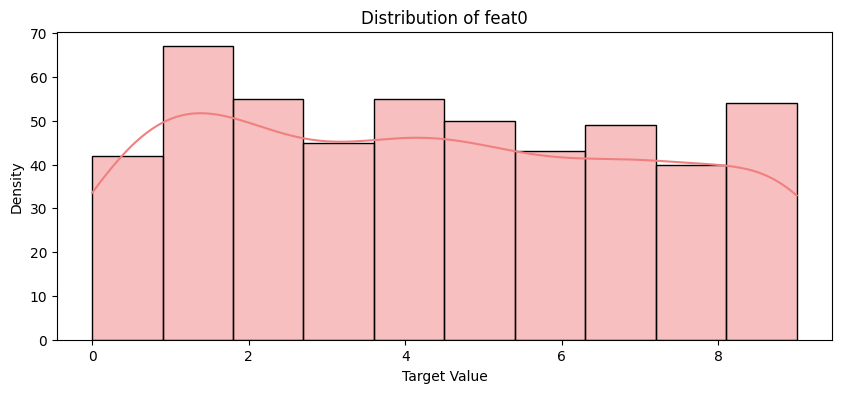

,counts,%
feat0,,
0,42,0.08
1,67,0.13
2,55,0.11
3,45,0.09
4,55,0.11
5,50,0.10
6,43,0.09
7,49,0.10
8,40,0.08


In [122]:
target_info = target_info(df_raw, 'feat0').sort_index()
target_info

This looks like the same story, the first column is a label.

In [ ]:
df = df_raw.drop(columns=['feat0'])

### Data overview and typing

In [12]:
duplicates_df = df[df.duplicated()]
duplicates_df

,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,feat9,feat10,...,feat775,feat776,feat777,feat778,feat779,feat780,feat781,feat782,feat783,feat784


In [13]:
df.describe()

,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,feat9,feat10,...,feat775,feat776,feat777,feat778,feat779,feat780,feat781,feat782,feat783,feat784
count,500.0,500.0,500.0,500.0,500.0,500.0,500.0,500.0,500.0,500.0,...,500.000000,500.000000,500.0,500.0,500.0,500.0,500.0,500.0,500.0,500.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.506000,0.256000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,11.314504,5.724334,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,253.000000,128.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
constant_features = df.columns[df.var() == 0.0].tolist()
print(f"Constant features ({len(constant_features)}: {constant_features}")

Constant features (209: ['feat1', 'feat2', 'feat3', 'feat4', 'feat5', 'feat6', 'feat7', 'feat8', 'feat9', 'feat10', 'feat11', 'feat12', 'feat13', 'feat14', 'feat15', 'feat16', 'feat17', 'feat18', 'feat19', 'feat20', 'feat21', 'feat22', 'feat23', 'feat24', 'feat25', 'feat26', 'feat27', 'feat28', 'feat29', 'feat30', 'feat31', 'feat32', 'feat33', 'feat34', 'feat35', 'feat36', 'feat37', 'feat41', 'feat42', 'feat43', 'feat44', 'feat45', 'feat46', 'feat47', 'feat48', 'feat49', 'feat50', 'feat51', 'feat52', 'feat53', 'feat54', 'feat55', 'feat56', 'feat57', 'feat58', 'feat59', 'feat60', 'feat61', 'feat62', 'feat63', 'feat64', 'feat65', 'feat79', 'feat80', 'feat81', 'feat82', 'feat83', 'feat84', 'feat85', 'feat86', 'feat87', 'feat88', 'feat89', 'feat90', 'feat91', 'feat109', 'feat110', 'feat111', 'feat112', 'feat113', 'feat114', 'feat115', 'feat116', 'feat139', 'feat140', 'feat141', 'feat142', 'feat143', 'feat144', 'feat168', 'feat169', 'feat170', 'feat171', 'feat196', 'feat197', 'feat198', 'fe

Looks like the majority of pixels are just empty, they are background. They carry no essential information. A column with zero variance is mathematically incapable of contributing to any distance calculation. We might as well just leave them be to be handled by PCA as an experiment, but it will only slow it down if anything.

In [16]:
df = df.drop(columns=constant_features)

In [17]:
df.dtypes

feat38     int64
feat39     int64
feat40     int64
feat66     int64
feat67     int64
           ...  
feat772    int64
feat773    int64
feat774    int64
feat775    int64
feat776    int64
Length: 575, dtype: object

### Data visualization

I see no point in build this many features, knowing already that these are pixels with a lot of background. We might plot after reducing the dimensions though. 
In order to properly analyze feature space, we ought to deal with null values and outliers first. PCA can't handle nulls and is sensitive to outliers.

### Missing values overview

In [18]:
df_nulls = get_null_info(df)
df_nulls

No missing values are found in the data_frame


""


### Outlier detection

Sine Pixel intensities are bounded [0,255] by construction — there are no "extreme value" outliers the way there are in price or sensor data. The only kind of "outlier" in MNIST is a whole image that's unusually drawn (a bizarre 7, a smudge), and that's a multivariate, whole-row phenomenon. If considering, should be done after PCA.

### Scaling

standard StandardScaler can backfire on images. Pixels that are nonzero in only a handful of images get divided by a tiny std, exploding their values.

### Dimensionality reduction

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
import matplotlib.pyplot as plt

# ── Fit PCA on scaled data ─────────────────────────────────────────────────────
# Scaling is mandatory — PCA maximizes variance, and an unscaled large-unit
# feature would dominate purely because of its units, not its importance.
pca_pipeline = Pipeline([
    ('scaler', FunctionTransformer(lambda df: df.copy() / 255)), # or regular StandardScaler() if not pixel data
    ('pca', PCA(
        n_components=None,              # None = keep all, decide k after
        random_state=RANDOM_SEED,
        )),
])

pca_pipeline.fit(df)
pca = pca_pipeline.named_steps['pca']

# ── Explained variance: how many components to keep ────────────────────────────
# a list of percentages that tells you how much information (variance) that specific Principal Component captures from the original data
# For example, if the first value is 0.40, it means Principal Component 1 holds 40% of your total data's variance.
explained = pca.explained_variance_ratio_

# how much total information will be kept if we cut off
# for example, pc1 = pc1, pc2 = pc1+pc2, pc3=pc1+pc2+pc3 etc. Decided to drop to 2D the total remaining data is: (pc1+pc2)%
cumulative = np.cumsum(explained)
# return the very first index of max element (True that is), adding 1 to account for 0 index
# jt returns the number of components to keep to retain 95% of information
k_95 = np.argmax(cumulative >= 0.95) + 1
print(f"Components to retain 95% variance: {k_95}")
print(f"Sanity check. Variance explained by first {k_95}: {cumulative[k_95-1]:.4f}")

Components to retain 95% variance: 114
Sanity check. Variance explained by first 114: 0.9500


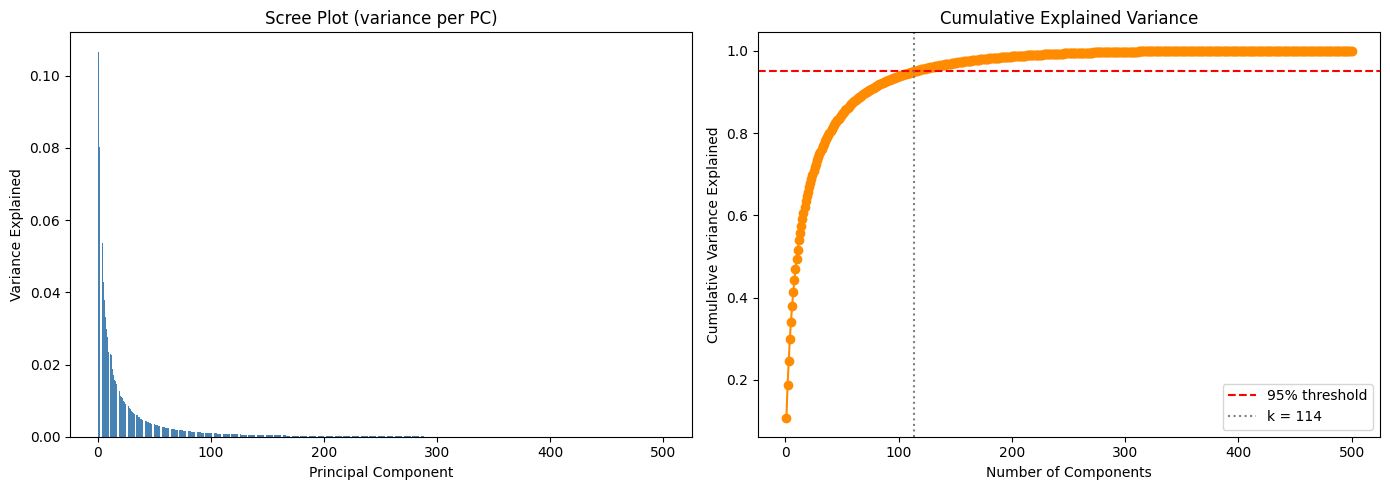

In [54]:
# ── Scree plot + cumulative curve ──────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

max_display = 500
x_range = range(1, max_display + 1)

ax1.bar(x_range, explained[:max_display], color='steelblue')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Variance Explained')
ax1.set_title('Scree Plot (variance per PC)')

ax2.plot(range(1, len(cumulative) + 1), cumulative, 'o-', color='darkorange')
ax2.axhline(0.95, color='red', linestyle='--', label='95% threshold')
ax2.axvline(k_95, color='gray', linestyle=':', label=f'k = {k_95}')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance Explained')
ax2.set_title('Cumulative Explained Variance')
ax2.legend()

plt.tight_layout()
plt.show()


The scree plot confirms the explained variance drop off after a value for PC100. The selected base threshold of 0.95 (PC114) is correct and shall not be changed.

In [ ]:
# ── Refit with chosen k and transform ──────────────────────────────────────────
final_pca = Pipeline([
    ('scaler', FunctionTransformer(lambda df: df.copy() / 255)),
    ('pca', PCA(n_components=k_95, random_state=RANDOM_SEED)),
])
X_reduced = final_pca.fit_transform(df)   # shape: (n_samples, k_95)
print(f"Reduced shape: {X_reduced.shape}")

# ── Inspect loadings (which features drive each PC) ─────────────────────────────
# Rows = PCs, columns = original features. Large |value| = strong contribution.
loadings = pd.DataFrame(
    final_pca.named_steps['pca'].components_,
    columns=df.columns,
    index=[f'PC{i+1}' for i in range(k_95)],
)
print("\nTop feature loadings for PC1:")
print(loadings.loc['PC1'].abs().sort_values(ascending=False).head(5))

Reduced shape: (500, 114)

Top feature loadings for PC1:
feat579    0.104800
feat606    0.104498
feat551    0.103769
feat318    0.100457
feat552    0.099510
Name: PC1, dtype: float64


In [61]:
X_reduced.shape

(500, 114)

In [92]:
df_raw

,feat0,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,feat9,...,feat775,feat776,feat777,feat778,feat779,feat780,feat781,feat782,feat783,feat784
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
496,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
497,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Flagged 5 of 500 images (1.0%)


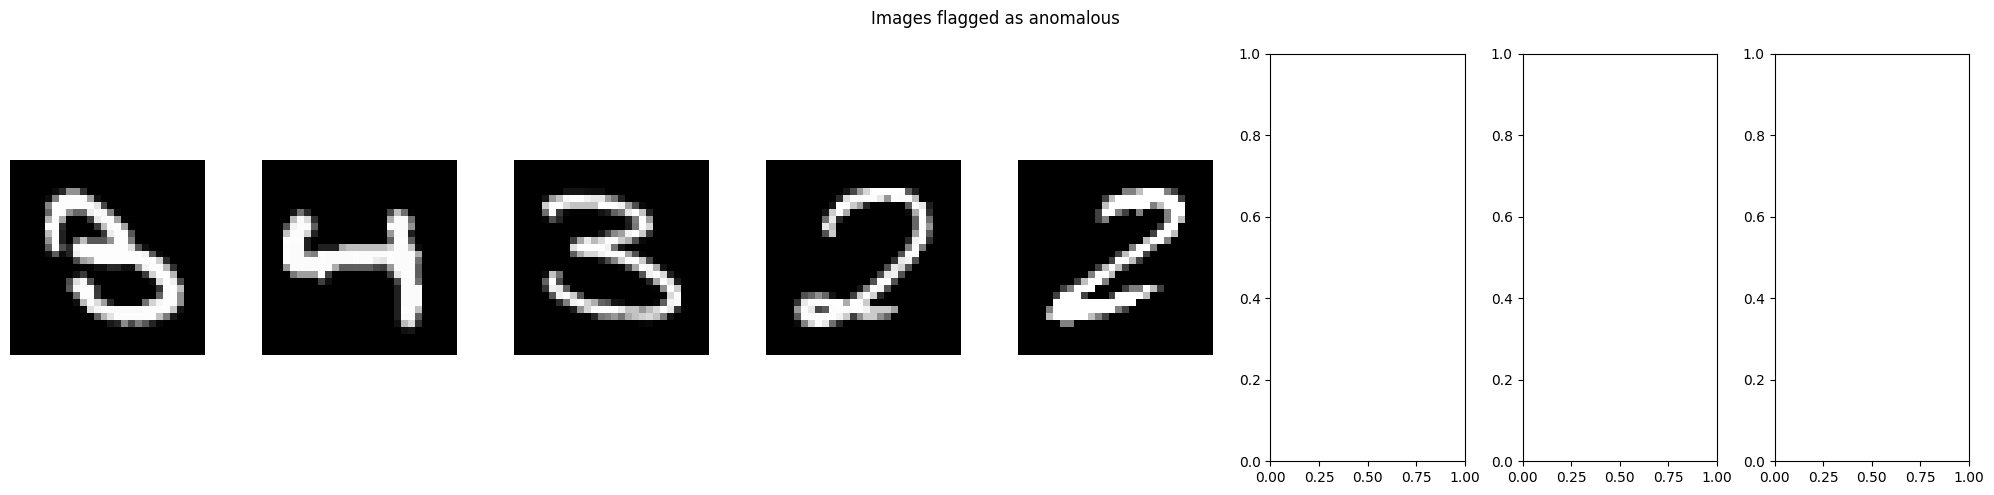

In [100]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.01, random_state=RANDOM_SEED)
flags = iso.fit_predict(X_reduced)        # -1 = unusual, 1 = normal

# 1. How many were flagged?
n_outliers = (flags == -1).sum()
print(f"Flagged {n_outliers} of {len(flags)} images ({n_outliers/len(flags):.1%})")

# 2. SEE the flagged images — this is the actual decision step.
#    Reshape original pixel rows back to 28x28 to look at them.
outlier_idx = np.where(flags == -1)[0]

fig, axes = plt.subplots(1, 8, figsize=(20, 5))
for ax, idx in zip(axes.ravel(), outlier_idx[:16], strict=False):
    ax.imshow(df_raw.drop(columns=['feat0']).iloc[idx].to_numpy().reshape(28, -1), cmap='gray') # NumPy auto-calculates 25
    ax.axis('off')
fig.suptitle("Images flagged as anomalous")
plt.tight_layout()
plt.show()

### K-means clustering

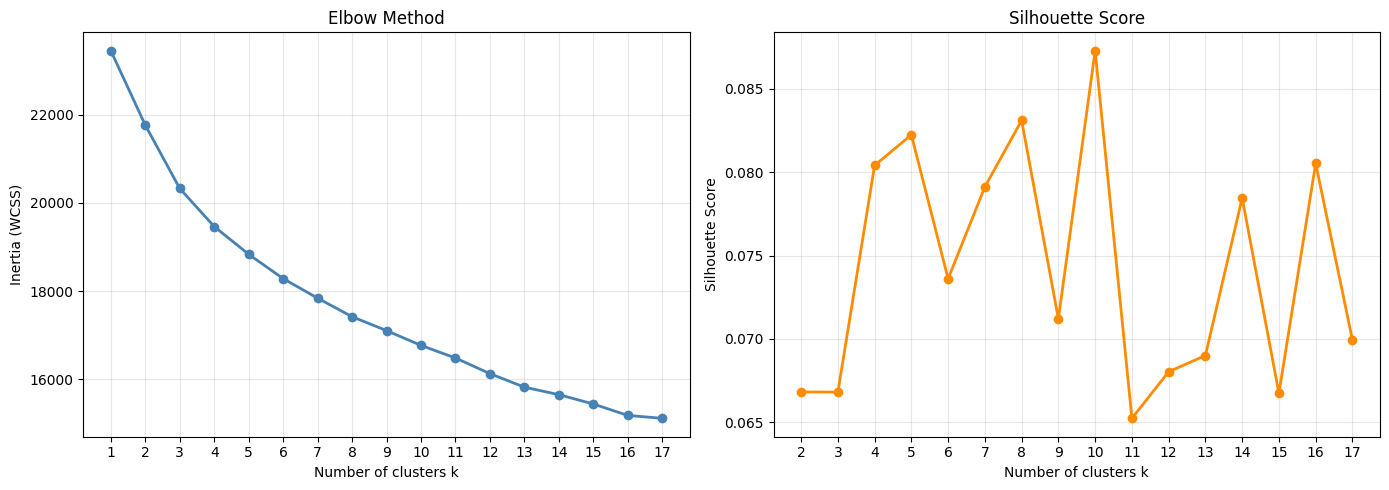

In [106]:
# ----- STEP 1: Fit the model -----
k_range = range(1, 18)                  # presumable number of clusters to try out
inertias = []                           # inertias to accumulate
silhouette_scores = []                  # silhouette scores to accumulate

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',           # smart initialization — industry standard
        n_init=10,                  # run 10 times for current k, return the lowest-inertia result
        max_iter=300,               # fallback convergence cap (to prevent infinite loops on non-converging initializations)
        random_state=RANDOM_SEED,
    )
    kmeans.fit(X_reduced)
    inertias.append(kmeans.inertia_)

    # silhouette undefined for k=1 (only one cluster, no comparison possible)
    if k >= 2:
        silhouette_scores.append(silhouette_score(X_reduced, kmeans.labels_))
    else:
        silhouette_scores.append(None)

# ----- STEP 2: Plotting -----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- PLOT 1: Elbow plot ---
ax1.plot(k_range, inertias, 'o-', color='steelblue', linewidth=2)
ax1.set_xlabel('Number of clusters k')
ax1.set_ylabel('Inertia (WCSS)')
ax1.set_title('Elbow Method')
ax1.set_xticks(list(k_range))
ax1.grid(True, alpha=0.3)

# --- PLOT 2: Silhouette plot ---
valid_k = [k for k in k_range if k >= 2]                                    # exclude k=1 from Silhouette scores
valid_scores = [s for s in silhouette_scores if s is not None]              # exclude k=1 from Silhouette scores
ax2.plot(valid_k, valid_scores, 'o-', color='darkorange', linewidth=2)
ax2.set_xlabel('Number of clusters k')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score')
ax2.set_xticks(valid_k)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

This is a wonderful example of when the Elbow method is wrong. Based on it, we are supposed to have 3 classes, which is definitely wrong. The signal of Silhouette Score is strong and firmly suggests 10 clusters. The highest score is < 0.09 and the scores overall are close to 0 - this is evidence of the fact that points sit near a cluster boundary - the ambiguous assignment. Surely, the optimal $k$ is the one where the elbow and the silhouette peak agree. When they disagree, it is standard to prefer the silhouette - it is a direct, interpretable measure of cluster quality rather than a visual judgment call.

In [129]:
# ----- Fit final model at chosen k -----
OPTIMAL_K = 10

final_pipeline = Pipeline([
    ('scaler', FunctionTransformer(lambda df: df.copy() / 255)),
    ('pca', PCA(n_components=k_95, random_state=RANDOM_SEED)),
    ('kmeans', KMeans(
        n_clusters=OPTIMAL_K,
        init='k-means++',
        n_init=10,
        max_iter=300,
        random_state=RANDOM_SEED,
    )),
])

final_pipeline.fit(df)
labels = final_pipeline.named_steps['kmeans'].labels_

print(f"Chosen k: {OPTIMAL_K}")
print(f"Final inertia: {final_pipeline.named_steps['kmeans'].inertia_:.4f}")
print(f"Silhouette score: {silhouette_score(final_pipeline.named_steps['scaler'].transform(X_reduced), labels):.4f}")
print(f"Cluster sizes: {dict(zip(*np.unique(labels, return_counts=True), strict=True))}")

Chosen k: 10
Final inertia: 16772.1406
Silhouette score: 0.0873
Cluster sizes: {0: 29, 1: 55, 2: 33, 3: 94, 4: 49, 5: 74, 6: 36, 7: 40, 8: 67, 9: 23}


Since we have the actual labels, we're able to assess the quality

In [131]:
from sklearn.metrics import classification_report

y_true = df_raw['feat0']
y_pred = final_pipeline.predict(df)

In [135]:
report = classification_report(y_true, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        42
           1       0.00      0.00      0.00        67
           2       0.12      0.07      0.09        55
           3       0.06      0.13      0.09        45
           4       0.00      0.00      0.00        55
           5       0.19      0.28      0.23        50
           6       0.86      0.72      0.78        43
           7       0.85      0.69      0.76        49
           8       0.01      0.03      0.02        40
           9       0.00      0.00      0.00        54

    accuracy                           0.18       500
   macro avg       0.21      0.19      0.20       500
weighted avg       0.20      0.18      0.18       500



### Conclusion

Cluster separation is ambiguous, K-means wasn't able to separate classes in classification sense, but managed to determine the number of clusters correctly. 